# 04 · Wine Quality — The Modeling Framework (leakage, stratification, QWK, baselines)

## Part 4 — The Modeling Framework

Before fitting a single serious model, we build the **scaffolding that makes every later result
trustworthy**. Three properties of this dataset each set a trap, and each needs a deliberate choice:

| trap | consequence if ignored | the fix |
|---|---|---|
| **18% duplicate rows** | a wine sits in train *and* test → inflated scores | `dedup()` **before** the split |
| **imbalanced target** | rare grades vanish from a fold; accuracy looks good for free | **stratified** split + k-fold |
| **ordinal target** | a 5→8 error is treated like a 5→6 error | score with **quadratic weighted kappa** |

This part demonstrates each trap concretely, defines the metric we'll live by, and establishes the
**baselines** every model in Parts 5–9 must beat. Get this wrong and every later number is a lie —
so it's worth doing slowly.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
raw = data.clean()
print("raw rows:", len(raw), "| deduped:", len(data.dedup(raw)))

setup ok | numpy 2.1.3 | pandas 2.3.3


raw rows: 6497 | deduped: 5320


### 1. The leakage trap, *demonstrated*

It's easy to *say* "duplicates cause leakage." Let's **prove it**. We train the same 1-nearest-neighbour
classifier two ways — once on the data with duplicates kept, once deduped — using an identical
stratified split. With duplicates, many test wines have an **exact twin** in the training set, so 1-NN
finds a perfect match and looks far better than it really is.

The gap between the two bars is *pure illusion* — accuracy bought by memorising leaked rows.

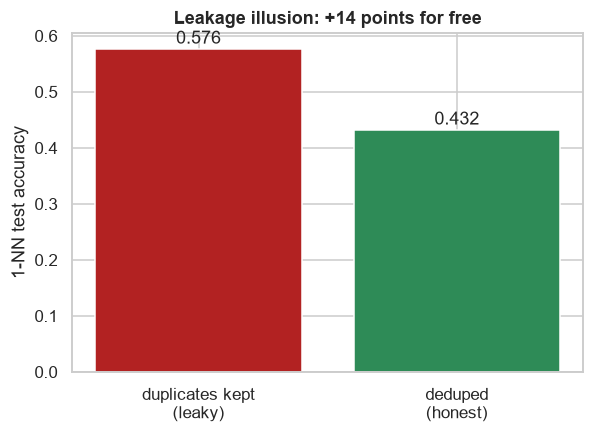

duplicates inflate 1-NN accuracy 0.576 -> deduped 0.432. We dedup before EVERY split from now on.


In [2]:
def knn_acc(dedup):
    X, y = M.prep(data.dedup(raw) if dedup else raw)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, stratify=y, random_state=0)
    return KNeighborsClassifier(1).fit(Xtr, ytr).score(Xte, yte)
dup, ded = knn_acc(False), knn_acc(True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["duplicates kept\n(leaky)", "deduped\n(honest)"], [dup, ded], color=["firebrick", "seagreen"])
ax.set_ylabel("1-NN test accuracy"); ax.set_title(f"Leakage illusion: +{100*(dup-ded):.0f} points for free")
for i, v in enumerate([dup, ded]): ax.text(i, v+.01, f"{v:.3f}", ha="center")
eda.savefig(fig, "p4_leakage.png"); plt.show()
print("duplicates inflate 1-NN accuracy %.3f -> deduped %.3f. We dedup before EVERY split from now on." % (dup, ded))

### 2. The stratified split

With only **5 wines at quality 9** in the whole dataset, a random split could easily put *all* of them
in training (or testing), leaving a fold that can neither learn nor be scored on that grade.
**Stratification** forces each grade to appear in train and test in the *same proportion*. The table
below shows the proportions matched almost exactly.

In [3]:
Xtr, Xte, ytr, yte = M.split(raw)   # dedup -> engineer -> stratified 75/25 split
prop = pd.DataFrame({"train %": ytr.value_counts(normalize=True).sort_index()*100,
                     "test %":  yte.value_counts(normalize=True).sort_index()*100}).round(1)
print("train %d wines / test %d wines | features: %d" % (len(ytr), len(yte), Xtr.shape[1]))
print(prop.to_string())
print("\nq9 -> train %d, test %d (both non-empty thanks to stratification)" % ((ytr==9).sum(), (yte==9).sum()))

train 3990 wines / test 1330 wines | features: 16
         train %  test %
quality                 
3            0.6     0.6
4            3.9     3.8
5           32.9    32.9
6           43.7    43.7
7           16.1    16.1
8            2.8     2.8
9            0.1     0.1

q9 -> train 4, test 1 (both non-empty thanks to stratification)


### 3. The framing fork — three ways to model an ordinal target

`quality` is **ordinal**: ordered (8 > 7 > 6) but not necessarily evenly spaced. That gives three
modelling stances, each with a different blind spot:

- **Classification** (predict the grade as a *category*). Simple, gives per-class probabilities — but
  *throws away the order*: to a plain classifier, mistaking a 5 for an 8 is no worse than a 5 for a 6.
- **Regression** (predict a *number*, then round). *Respects order* and naturally penalises far misses
  — but assumes the grades are **evenly spaced** (that 5→6 is the same "distance" as 8→9).
- **Ordinal regression** (fit K−1 cumulative "is quality > k?" models). The honest middle: uses the
  order *without* assuming equal spacing — at the cost of complexity.

We'll try **all three** (classification in Part 5, regression & ordinal in Part 6) and let the metric
decide. The metric, therefore, must itself understand order — which rules out plain accuracy.

### 4. The metric — Quadratic Weighted Kappa (QWK)

QWK is the standard score for ordinal ratings (it's what the wine and essay-grading literature use).
Read it as **agreement, corrected for chance, where being *far* off is penalised more than being
*close*** — the penalty for predicting grade *i* when the truth is *j* grows with the **square** of the
distance (i−j)². The heatmap below *is* that penalty matrix: the diagonal (correct) is free, and cost
rises sharply as you move away from it. Scale: **1** = perfect, **0** = no better than chance, **<0** =
worse than chance.

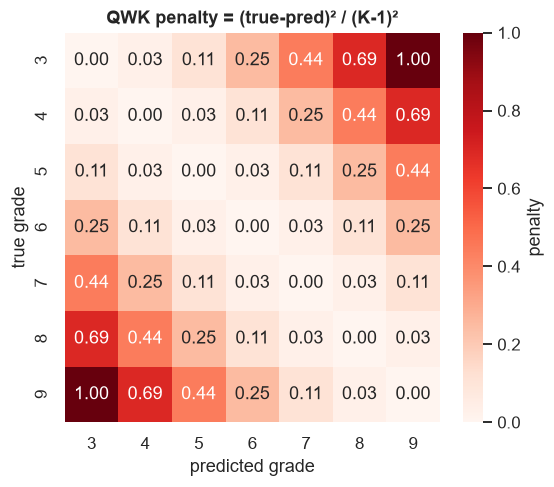

worked example — true grade 5:
  predict 6 (off by 1): QWK 0.800
  predict 8 (off by 3): QWK 0.082  <- far miss punished far harder


In [4]:
K = M.LABELS
W = (K[:, None] - K[None, :])**2 / (len(K)-1)**2
fig, ax = plt.subplots(figsize=(5.5, 4.6))
sns.heatmap(W, annot=True, fmt=".2f", xticklabels=K, yticklabels=K, cmap="Reds", cbar_kws={"label":"penalty"}, ax=ax)
ax.set_xlabel("predicted grade"); ax.set_ylabel("true grade"); ax.set_title("QWK penalty = (true-pred)² / (K-1)²")
eda.savefig(fig, "p4_qwk_weights.png"); plt.show()
print("worked example — true grade 5:")
print("  predict 6 (off by 1): QWK %.3f" % M.qwk([5,6,7,5,6], [6,6,7,5,6]))
print("  predict 8 (off by 3): QWK %.3f  <- far miss punished far harder" % M.qwk([5,6,7,5,6], [8,6,7,5,6]))

### 5. Cross-validation — one number is not enough

A single train/test split is noisy. **Stratified k-fold** rotates the test set through 5 disjoint
slices (each preserving the class balance) and reports the **mean ± spread** — a far more honest
estimate of how a model generalises. `modeling.cv_qwk` wraps this; here it is on the logistic
baseline.

In [5]:
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
Xall, yall = M.prep(data.dedup(raw))
cv = M.cv_qwk(logit, Xall, yall, n=5)
print("logistic 5-fold QWK: %.3f ± %.3f  (folds: %s)" % (cv.mean(), cv.std(), np.round(cv, 3)))

logistic 5-fold QWK: 0.459 ± 0.012  (folds: [0.456 0.465 0.47  0.437 0.469])


### 6. Baselines — the bar to beat (and proof that accuracy lies)

Three reference points: **majority** (always predict the most common grade, 6), **stratified random**
(guess in proportion to the class frequencies), and a **logistic** model. Look at the majority row:
**44% accuracy yet QWK = 0 and macro-F1 ≈ 0.09**. It has *zero* real skill — it just exploits the
imbalance. Accuracy alone would have called it a decent model. QWK, macro-F1 and MAE all see through
it; the logistic model is the first to show genuine signal (QWK ≈ 0.46).

                   accuracy  macro_F1    MAE    QWK
majority              0.437     0.087  0.643  0.000
stratified-random     0.336     0.140  0.931 -0.022
logistic              0.538     0.245  0.516  0.455


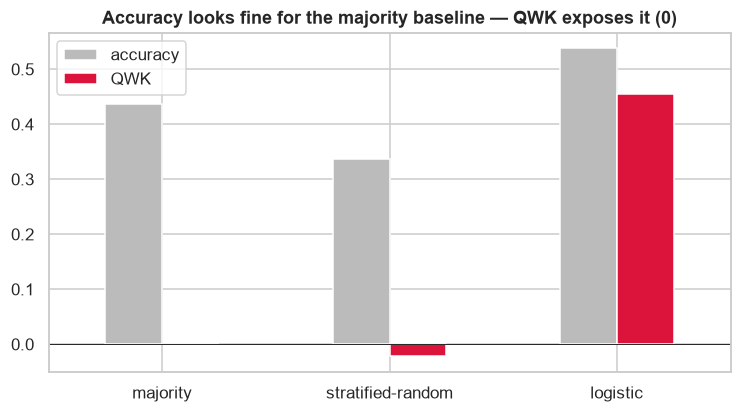

In [6]:
rows = []
for name, mdl in [("majority", DummyClassifier(strategy="most_frequent")),
                  ("stratified-random", DummyClassifier(strategy="stratified", random_state=0)),
                  ("logistic", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)))]:
    mdl.fit(Xtr, ytr); rows.append(M.report(yte, mdl.predict(Xte), name))
board = pd.DataFrame(rows)   # M.report returns named Series -> model names become the index
print(board.to_string())
fig, ax = plt.subplots(figsize=(8, 4))
board[["accuracy", "QWK"]].plot.bar(ax=ax, color=["#bbb", "crimson"], rot=0)
ax.set_title("Accuracy looks fine for the majority baseline — QWK exposes it (0)"); ax.axhline(0, color="k", lw=.6)
eda.savefig(fig, "p4_baselines.png"); plt.show()

### Takeaways

- **Leakage is not theoretical**: duplicates inflated 1-NN accuracy by ~14 points. `dedup()` runs
  before every split.
- **Stratification** keeps all seven grades (even quality 9, n=5) present in train and test.
- An **ordinal** target admits three framings (classify / regress / ordinal) — we test all three and
  let the metric arbitrate.
- That metric is **QWK**, which penalises far misses quadratically; we report **accuracy, macro-F1,
  MAE and QWK** together because *accuracy alone lies under imbalance* (majority baseline: 44% acc, 0
  QWK).
- The **bar to beat**: logistic QWK ≈ 0.46 (5-fold 0.46 ± small). Trees should do better — Part 5.

**Next — Part 5 (Classification models):** logistic vs random forest vs LightGBM, per-class metrics,
the confusion matrix, and the rare-grade problem that imbalance leaves behind.